# Dynamic Kinematics
While static posture evaluates geometry, Kinematics evaluates motion. In this notebook, we analyze the quality, direction, and energy of the subject's movement.

We will extract three features:

1. Kinetic Energy: The instantaneous energy of the movement.

2. Smoothness (SPARC & Jerk): The fluidity of the movement.

3. Direction Change: How sharply the subject is altering their trajectory.

## Loading the Data
We load our standard position tensor, but this time we also explicitly need the Velocity tensor, as kinematics are defined by speed and acceleration over time.

In [1]:
import numpy as np
from utils.data_loader import load_qualisys_tsv
from utils.plot_utils import plot_feature_timeseries

# Load data into clean 3D tensors
pos_tensor, vel_tensor, _, marker_names = load_qualisys_tsv("data/trial0001_impulsive.tsv")
hand_idx = marker_names.index("HAND_RIGHT")

N_frames, N_joints, N_dims = pos_tensor.shape
print(f"Loaded {N_frames} frames tracking {N_joints} joints.")

Loaded 7289 frames tracking 26 joints.


## Time-Series vs. Instantaneous Windows

Here we see the true power of the `SlidingWindow` architecture.
- **Smoothness and Direction Change** are *Dynamic Features*. To know if a movement is smooth or changing direction, the algorithm must look at the historical trajectory. We give them a long window (e.g., 60 frames).
- **Kinetic Energy** evaluates the instantaneous state ($E_k = \frac{1}{2}mv^2$). Because we already calculated the velocity, the feature only needs to look at the *current frame*. We give it a window of exactly 1.

We will also use the `metrics` argument to explicitly choose which mathematical outputs we want from features that offer multiple options.

In [2]:
from pyeyesweb.data_models.sliding_window import SlidingWindow
from pyeyesweb.low_level.smoothness import Smoothness
from pyeyesweb.low_level.direction_change import DirectionChange
from pyeyesweb.low_level.kinetic_energy import KineticEnergy

# 1. Initialize Windows
# Dynamic Windows (Require history)
sw_speed = SlidingWindow(max_length=60, n_signals=1, n_dims=1)
sw_pos_traj = SlidingWindow(max_length=60, n_signals=N_joints, n_dims=3)

# Static Window (Requires only the current instant)
sw_vel = SlidingWindow(max_length=1, n_signals=N_joints, n_dims=3)

# 2. Initialize Features
smooth_feature = Smoothness(rate_hz=100.0, metrics=["sparc", "jerk_rms"])
direction_feature = DirectionChange(metrics=["polygon"]) # Uses polygon area enclosed by the trajectory
energy_feature = KineticEnergy(weights=1.0, labels=marker_names)

## The Execution Loop
As we iterate through the frames, notice how we wait for the *longest* window to fill up before we start saving our computations. This prevents mathematical artifacts (like exploding Jerk calculations) from corrupting our data at the start of the trial.

C:\Users\Nicola\miniconda3\envs\pyeyesweb\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing Kinematics: 100%|██████████| 7289/7289 [00:04<00:00, 1529.51it/s]


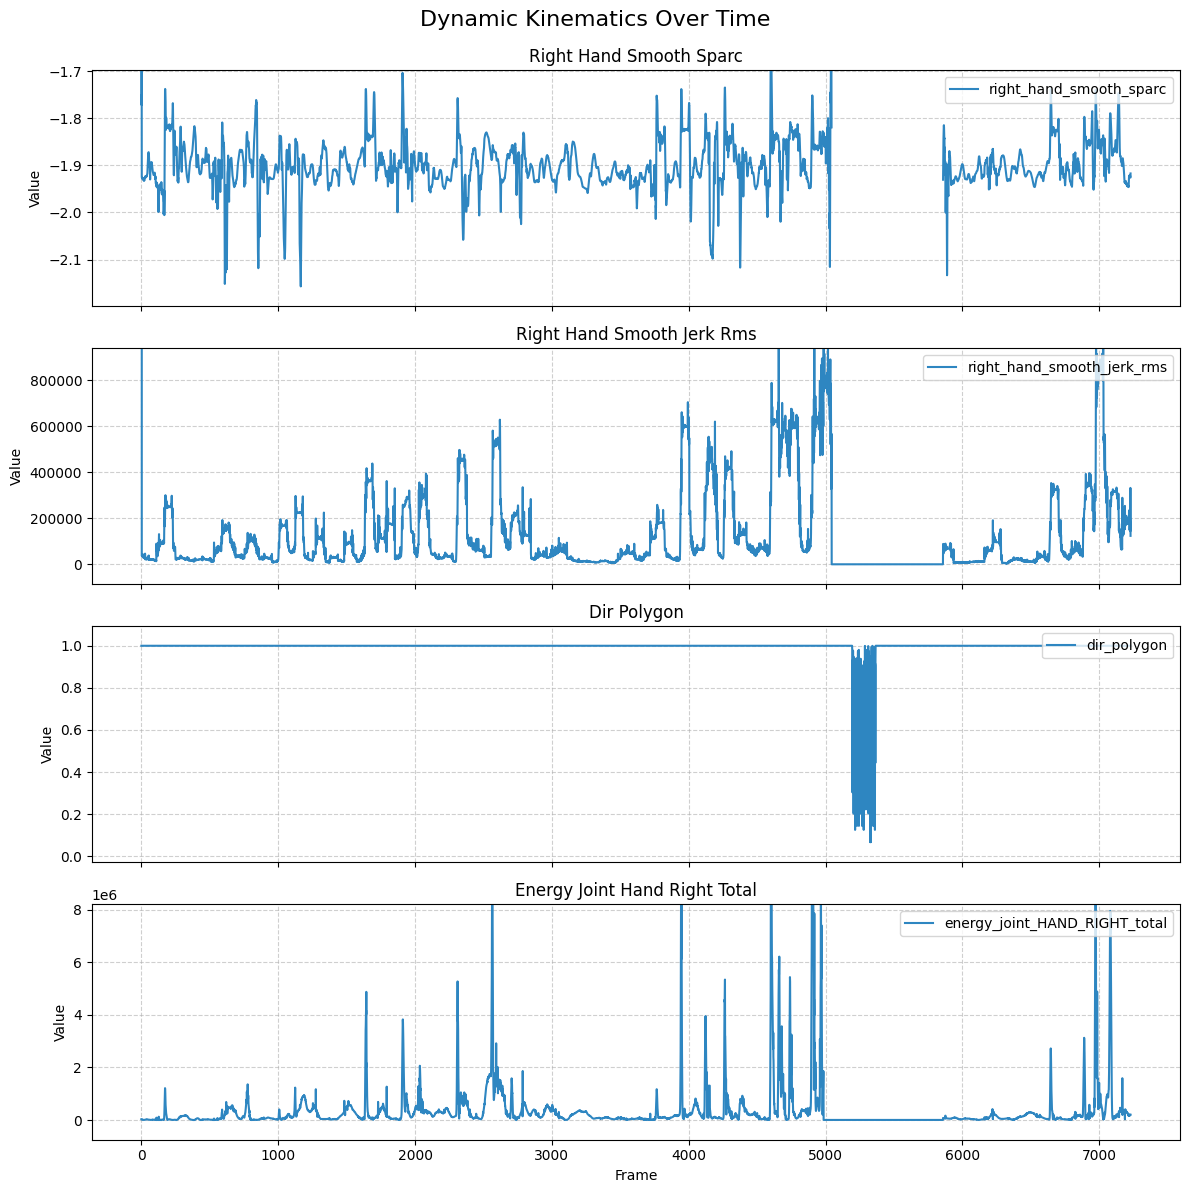

In [3]:
from tqdm.auto import tqdm

results = []

for pos_frame, vel_frame in tqdm(zip(pos_tensor, vel_tensor), total=N_frames, desc="Processing Kinematics"):

    # 1. Update Windows
    sw_pos_traj.append(pos_frame)
    sw_vel.append(vel_frame)

    # Smoothness expects a 1D scalar speed profile for a specific joint
    hand_speed = np.linalg.norm(vel_frame[hand_idx])
    sw_speed.append([[hand_speed]])

    # 2. Wait for the longest window to fill!
    if len(sw_pos_traj) < sw_pos_traj.max_length:
        continue

    # 3. Compute and Flatten
    res_smooth = smooth_feature(sw_speed).to_flat_dict("right_hand_smooth")
    res_dir = direction_feature(sw_pos_traj).to_flat_dict("dir")
    res_energy = energy_feature(sw_vel).to_flat_dict("energy")

    # 4. Merge dictionaries cleanly
    results.append(res_smooth | res_dir | res_energy)


# 5. Select exactly what we want to visualize
desired_metrics = [
    "right_hand_smooth_sparc",         # Spectral Arc Length (Fluidity)
    "right_hand_smooth_jerk_rms",      # Jerk (Abruptness)
    "dir_polygon",                     # Area enclosed by the trajectory turn
    "energy_joint_HAND_RIGHT_total"    # Total kinetic energy of the hand
]

plot_feature_timeseries(
    results_list=results,
    metrics_to_plot=desired_metrics,
    title="Dynamic Kinematics Over Time"
)

**Interpreting the Plot**

By stacking these kinematic features, we can build a comprehensive profile of the movement:

- **Energy vs. Smoothness**: Notice that when the Kinetic Energy spikes (fast movement), the SPARC metric might drop or Jerk might spike if the movement was abrupt and poorly controlled.

- **Direction Change**: A spike here indicates a sharp turn or reversal in the trajectory. High direction change paired with high Jerk usually indicates a highly impulsive, sudden movement!